# Statistical tests for Attack A

Updated version using the provided `Attack-A-Results.csv` file. The notebook now assumes the CSV contains only model-level results, without attacked-view flags such as `image_attack` or `sketch_attack`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import kruskal


In [2]:
DATA_PATH = Path('Attack-A-Results.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('./data/Attack-A-Results.csv')

MODEL_ORDER = ['1V', '2V']
LOSS_NAMES = ['Clean', 'FGSM', 'BIM']
VIEWS = ['IM', 'LA']
ATTACKS = ['FGSM', 'BIM']

MODEL_LABEL_MAP = {
    '1V': '1 View',
    '2V': '2 Views',
}

MODEL_COLOR_MAP = {
    '1V': 'tab:blue',
    '2V': 'tab:orange',
}

VIEW_LABEL_MAP = {
    'IM': 'Image',
    'LA': 'Label',
}

LOSS_COL_MAP = {
    view: {
        loss: f'{loss}_{view}_Loss'
        for loss in LOSS_NAMES
    }
    for view in VIEWS
}


In [3]:
df = pd.read_csv(DATA_PATH)

# Keep a consistent model order throughout the notebook.
df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
df = df.sort_values('model').reset_index(drop=True)

df.head()


,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,1V,0.007930,0.037863,0.009118,NaN,NaN,NaN
1,1V,0.008155,0.039692,0.009431,NaN,NaN,NaN
2,1V,0.007724,0.037606,0.008867,NaN,NaN,NaN
3,1V,0.007812,0.038582,0.008980,NaN,NaN,NaN
4,1V,0.007602,0.007602,0.007602,NaN,NaN,NaN


## Helper functions


In [4]:
def mean_losses(data, view):
    """Return mean Clean, FGSM, and BIM losses per model for one view."""
    loss_cols = list(LOSS_COL_MAP[view].values())

    return (
        data
        .groupby('model', observed=False)[loss_cols]
        .mean()
        .loc[MODEL_ORDER]
        .reset_index()
    )


def add_increase_columns(data, views=VIEWS, attacks=ATTACKS):
    """Add absolute and relative attack increases to a copy of the dataframe."""
    data = data.copy()

    for view in views:
        clean_col = f'Clean_{view}_Loss'

        for attack in attacks:
            attack_col = f'{attack}_{view}_Loss'
            abs_col = f'{attack}_{view}_Abs_Increase'
            rel_col = f'{attack}_{view}_Rel_Increase'

            data[abs_col] = data[attack_col] - data[clean_col]
            data[rel_col] = data[abs_col] / data[clean_col] * 100

    return data


def get_groups(data, value_col, group_col='model', model_order=MODEL_ORDER):
    """Return non-empty arrays per model, in the requested order."""
    return [
        data.loc[data[group_col].eq(model), value_col].dropna().to_numpy()
        for model in model_order
    ]


In [5]:
def plot_model_attack_losses(mean_df, view, model_order=MODEL_ORDER):
    """Plot Clean, FGSM, and BIM losses for each model. Colors represent models/views."""
    mean_df = mean_df.set_index('model').loc[model_order].reset_index()

    x = np.arange(len(LOSS_NAMES))
    width = 0.8 / len(model_order)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for i, model in enumerate(model_order):
        offset = (i - (len(model_order) - 1) / 2) * width
        values = [mean_df.loc[mean_df['model'].eq(model), LOSS_COL_MAP[view][loss]].iloc[0] for loss in LOSS_NAMES]

        ax.bar(
            x + offset,
            values,
            width,
            label=MODEL_LABEL_MAP[model],
            color=MODEL_COLOR_MAP[model],
        )

    ax.set_title(f'Mean {VIEW_LABEL_MAP[view]} Loss per Model and Attack Type', fontsize=20, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_xlabel('Attack type', fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels(LOSS_NAMES, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=12, title='Models', title_fontsize=14)

    plt.tight_layout()
    plt.show()


In [6]:
def plot_absolute_increases(data, view, model_order=MODEL_ORDER):
    """Plot mean absolute increase over the clean reconstruction loss."""
    increase_cols = [f'{attack}_{view}_Abs_Increase' for attack in ATTACKS]

    mean_df = (
        data
        .groupby('model', observed=False)[increase_cols]
        .mean()
        .loc[model_order]
        .reset_index()
    )

    x = np.arange(len(ATTACKS))
    width = 0.8 / len(model_order)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for i, model in enumerate(model_order):
        offset = (i - (len(model_order) - 1) / 2) * width
        values = [mean_df.loc[mean_df['model'].eq(model), f'{attack}_{view}_Abs_Increase'].iloc[0] for attack in ATTACKS]

        ax.bar(
            x + offset,
            values,
            width,
            label=MODEL_LABEL_MAP[model],
            color=MODEL_COLOR_MAP[model],
        )

    ax.set_title(f'Mean Absolute {VIEW_LABEL_MAP[view]} Loss Increase', fontsize=20, fontweight='bold')
    ax.set_ylabel('Absolute increase', fontsize=16)
    ax.set_xlabel('Attack type', fontsize=16)

    ax.set_xticks(x)
    ax.set_xticklabels(ATTACKS, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=12, title='Models', title_fontsize=14)

    plt.tight_layout()
    plt.show()


def plot_increase_boxplots(data, view, increase_type='Abs'):
    """Make notched boxplots for absolute or relative increases."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    positions, labels, box_data, colors = [], [], [], []
    pos = 1

    for attack in ATTACKS:
        for model in MODEL_ORDER:
            col = f'{attack}_{view}_{increase_type}_Increase'
            values = data.loc[data['model'].eq(model), col].dropna().to_numpy()

            positions.append(pos)
            labels.append(f'{attack}\n{MODEL_LABEL_MAP[model]}')
            box_data.append(values)
            colors.append(MODEL_COLOR_MAP[model])
            pos += 1

        pos += 0.5

    bp = ax.boxplot(
        box_data,
        positions=positions,
        notch=True,
        patch_artist=True,
        widths=0.55,
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ylabel = 'Absolute increase' if increase_type == 'Abs' else 'Relative increase (%)'
    ax.set_title(f'{VIEW_LABEL_MAP[view]} Loss Increase Distribution', fontsize=20, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_xlabel('Attack and model', fontsize=16)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    legend_handles = [
        Patch(facecolor=MODEL_COLOR_MAP[model], label=MODEL_LABEL_MAP[model], alpha=0.8)
        for model in MODEL_ORDER
    ]
    ax.legend(handles=legend_handles, fontsize=12, title='Models', title_fontsize=14)

    plt.tight_layout()
    plt.show()


## Mean loss plots


In [7]:
mean_image_loss = mean_losses(df, view='IM')
mean_image_loss


,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss
0,1V,0.007812,0.035207,0.008882
1,2V,0.007812,0.033329,0.008881


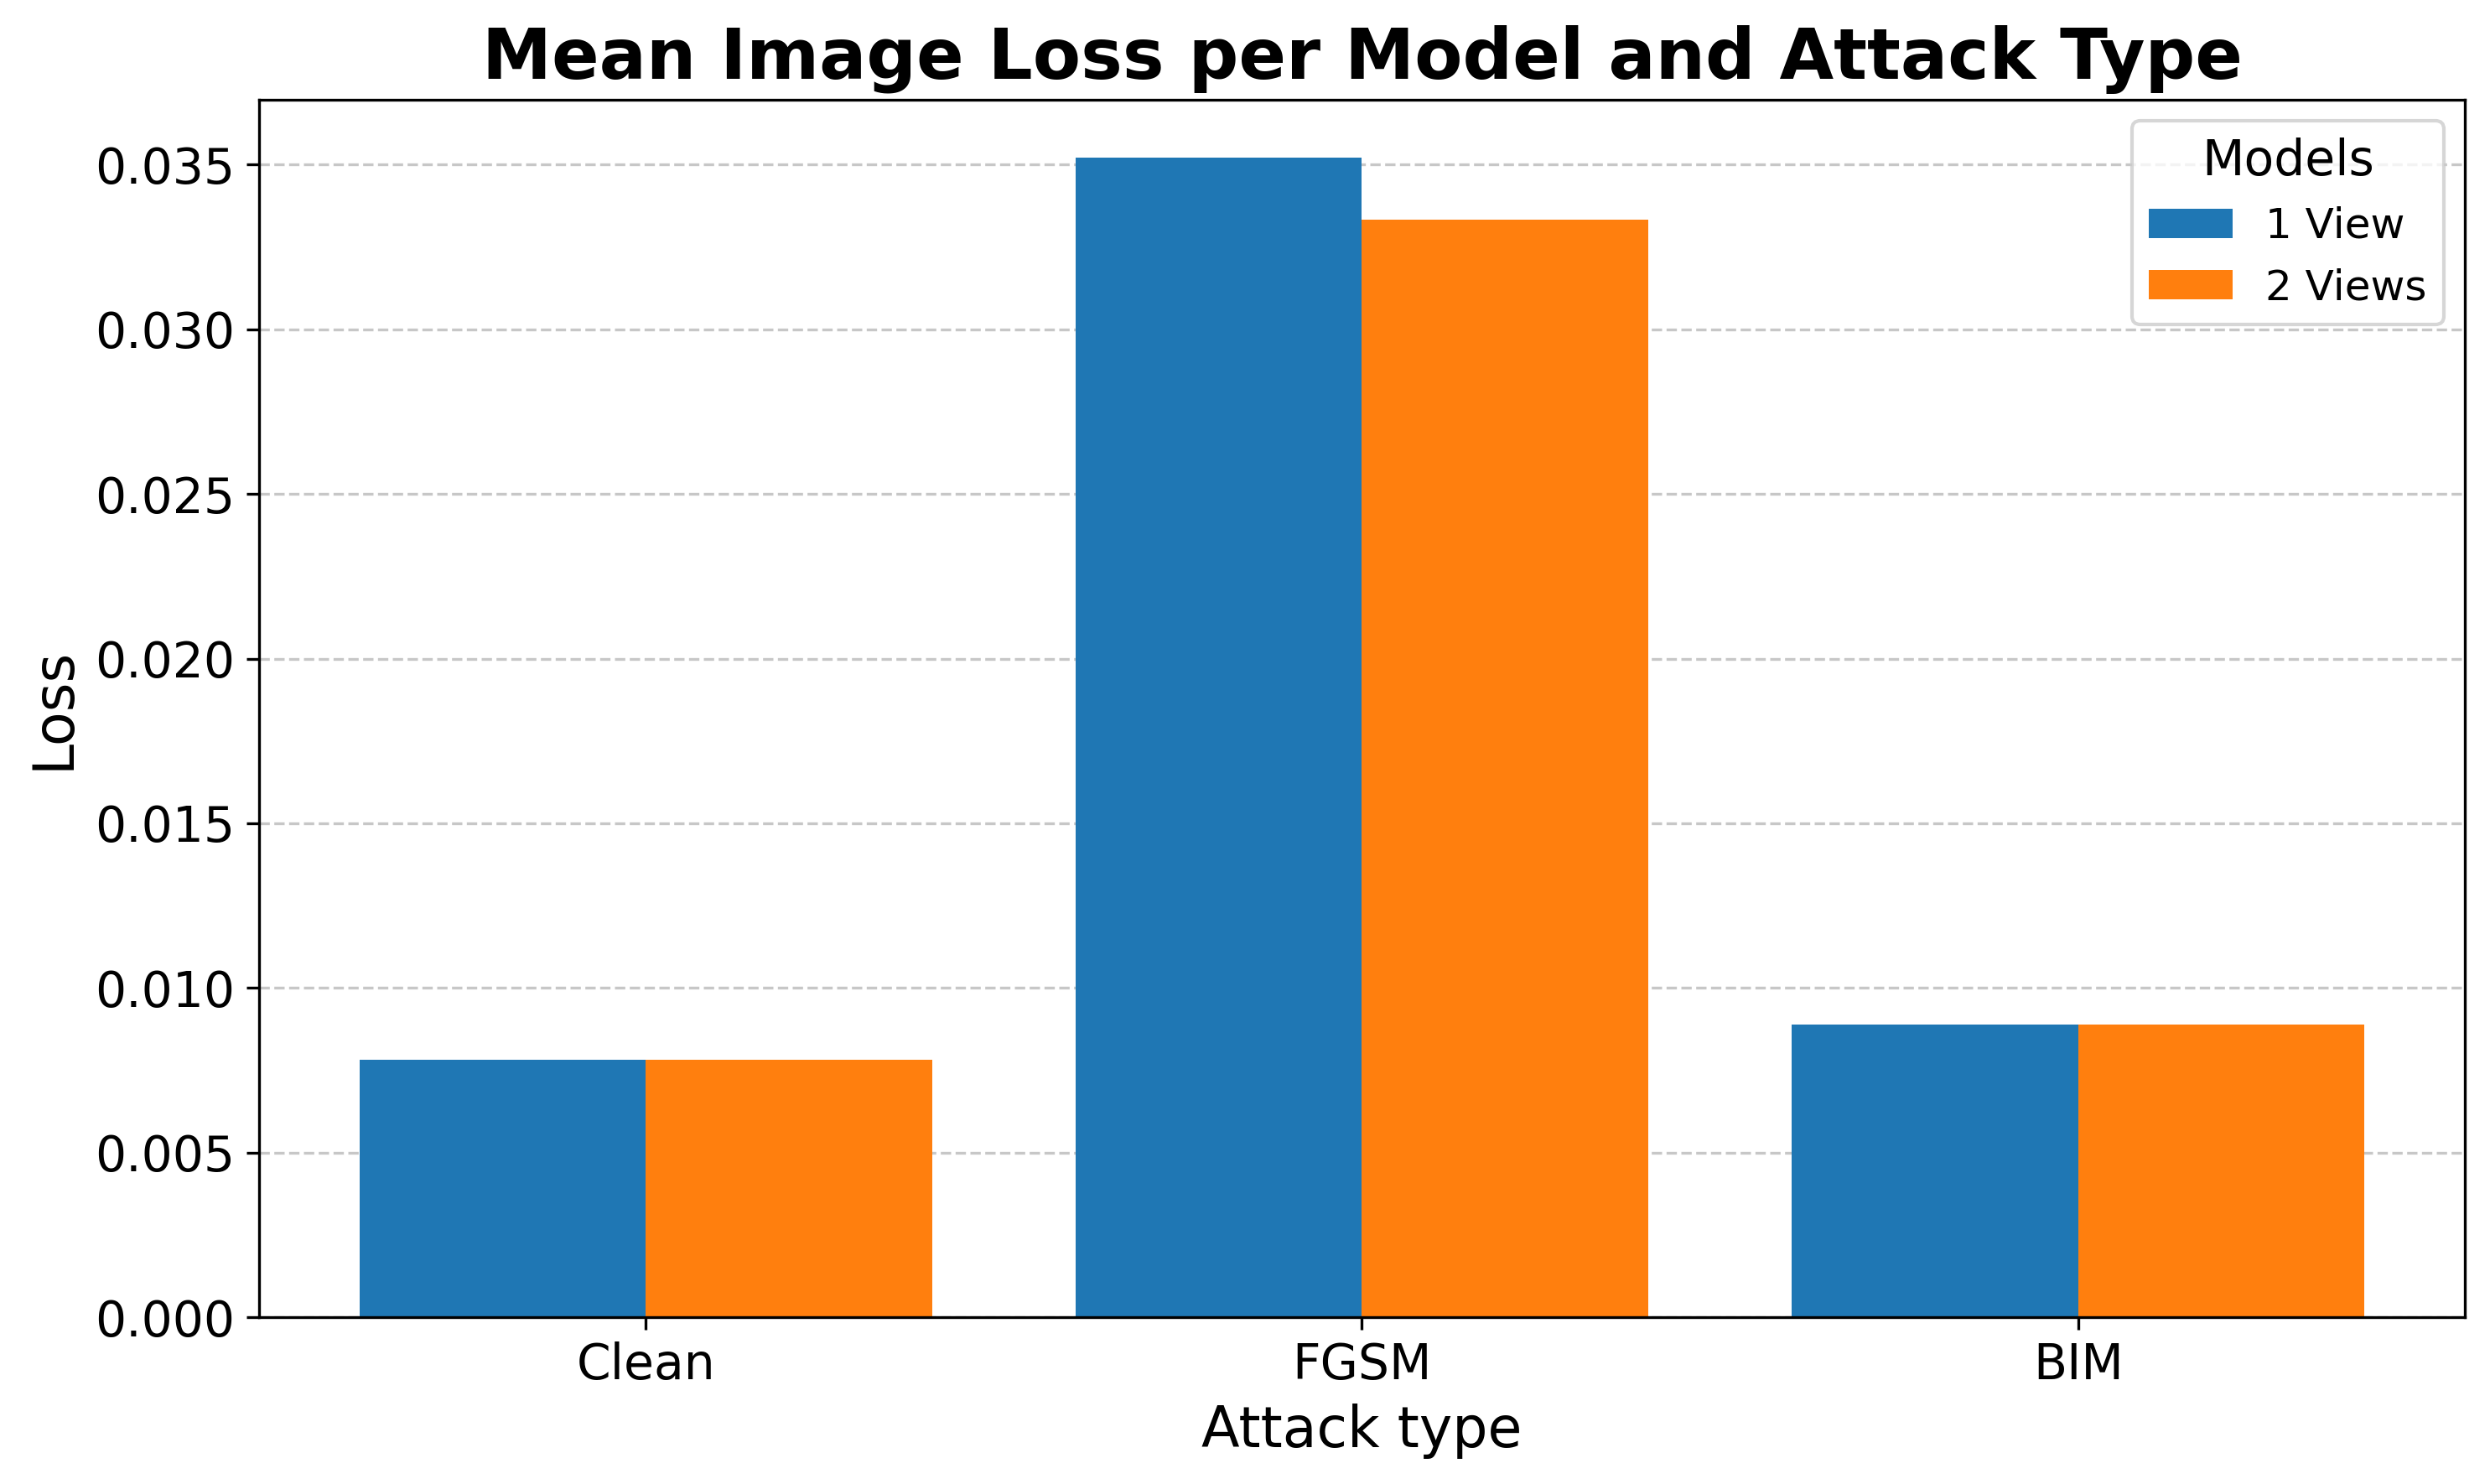

In [8]:
plot_model_attack_losses(mean_image_loss, view='IM')


In [9]:
mean_label_loss = mean_losses(df, view='LA')
mean_label_loss


,model,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,1V,NaN,NaN,NaN
1,2V,0.008813,1.869488,1.862777


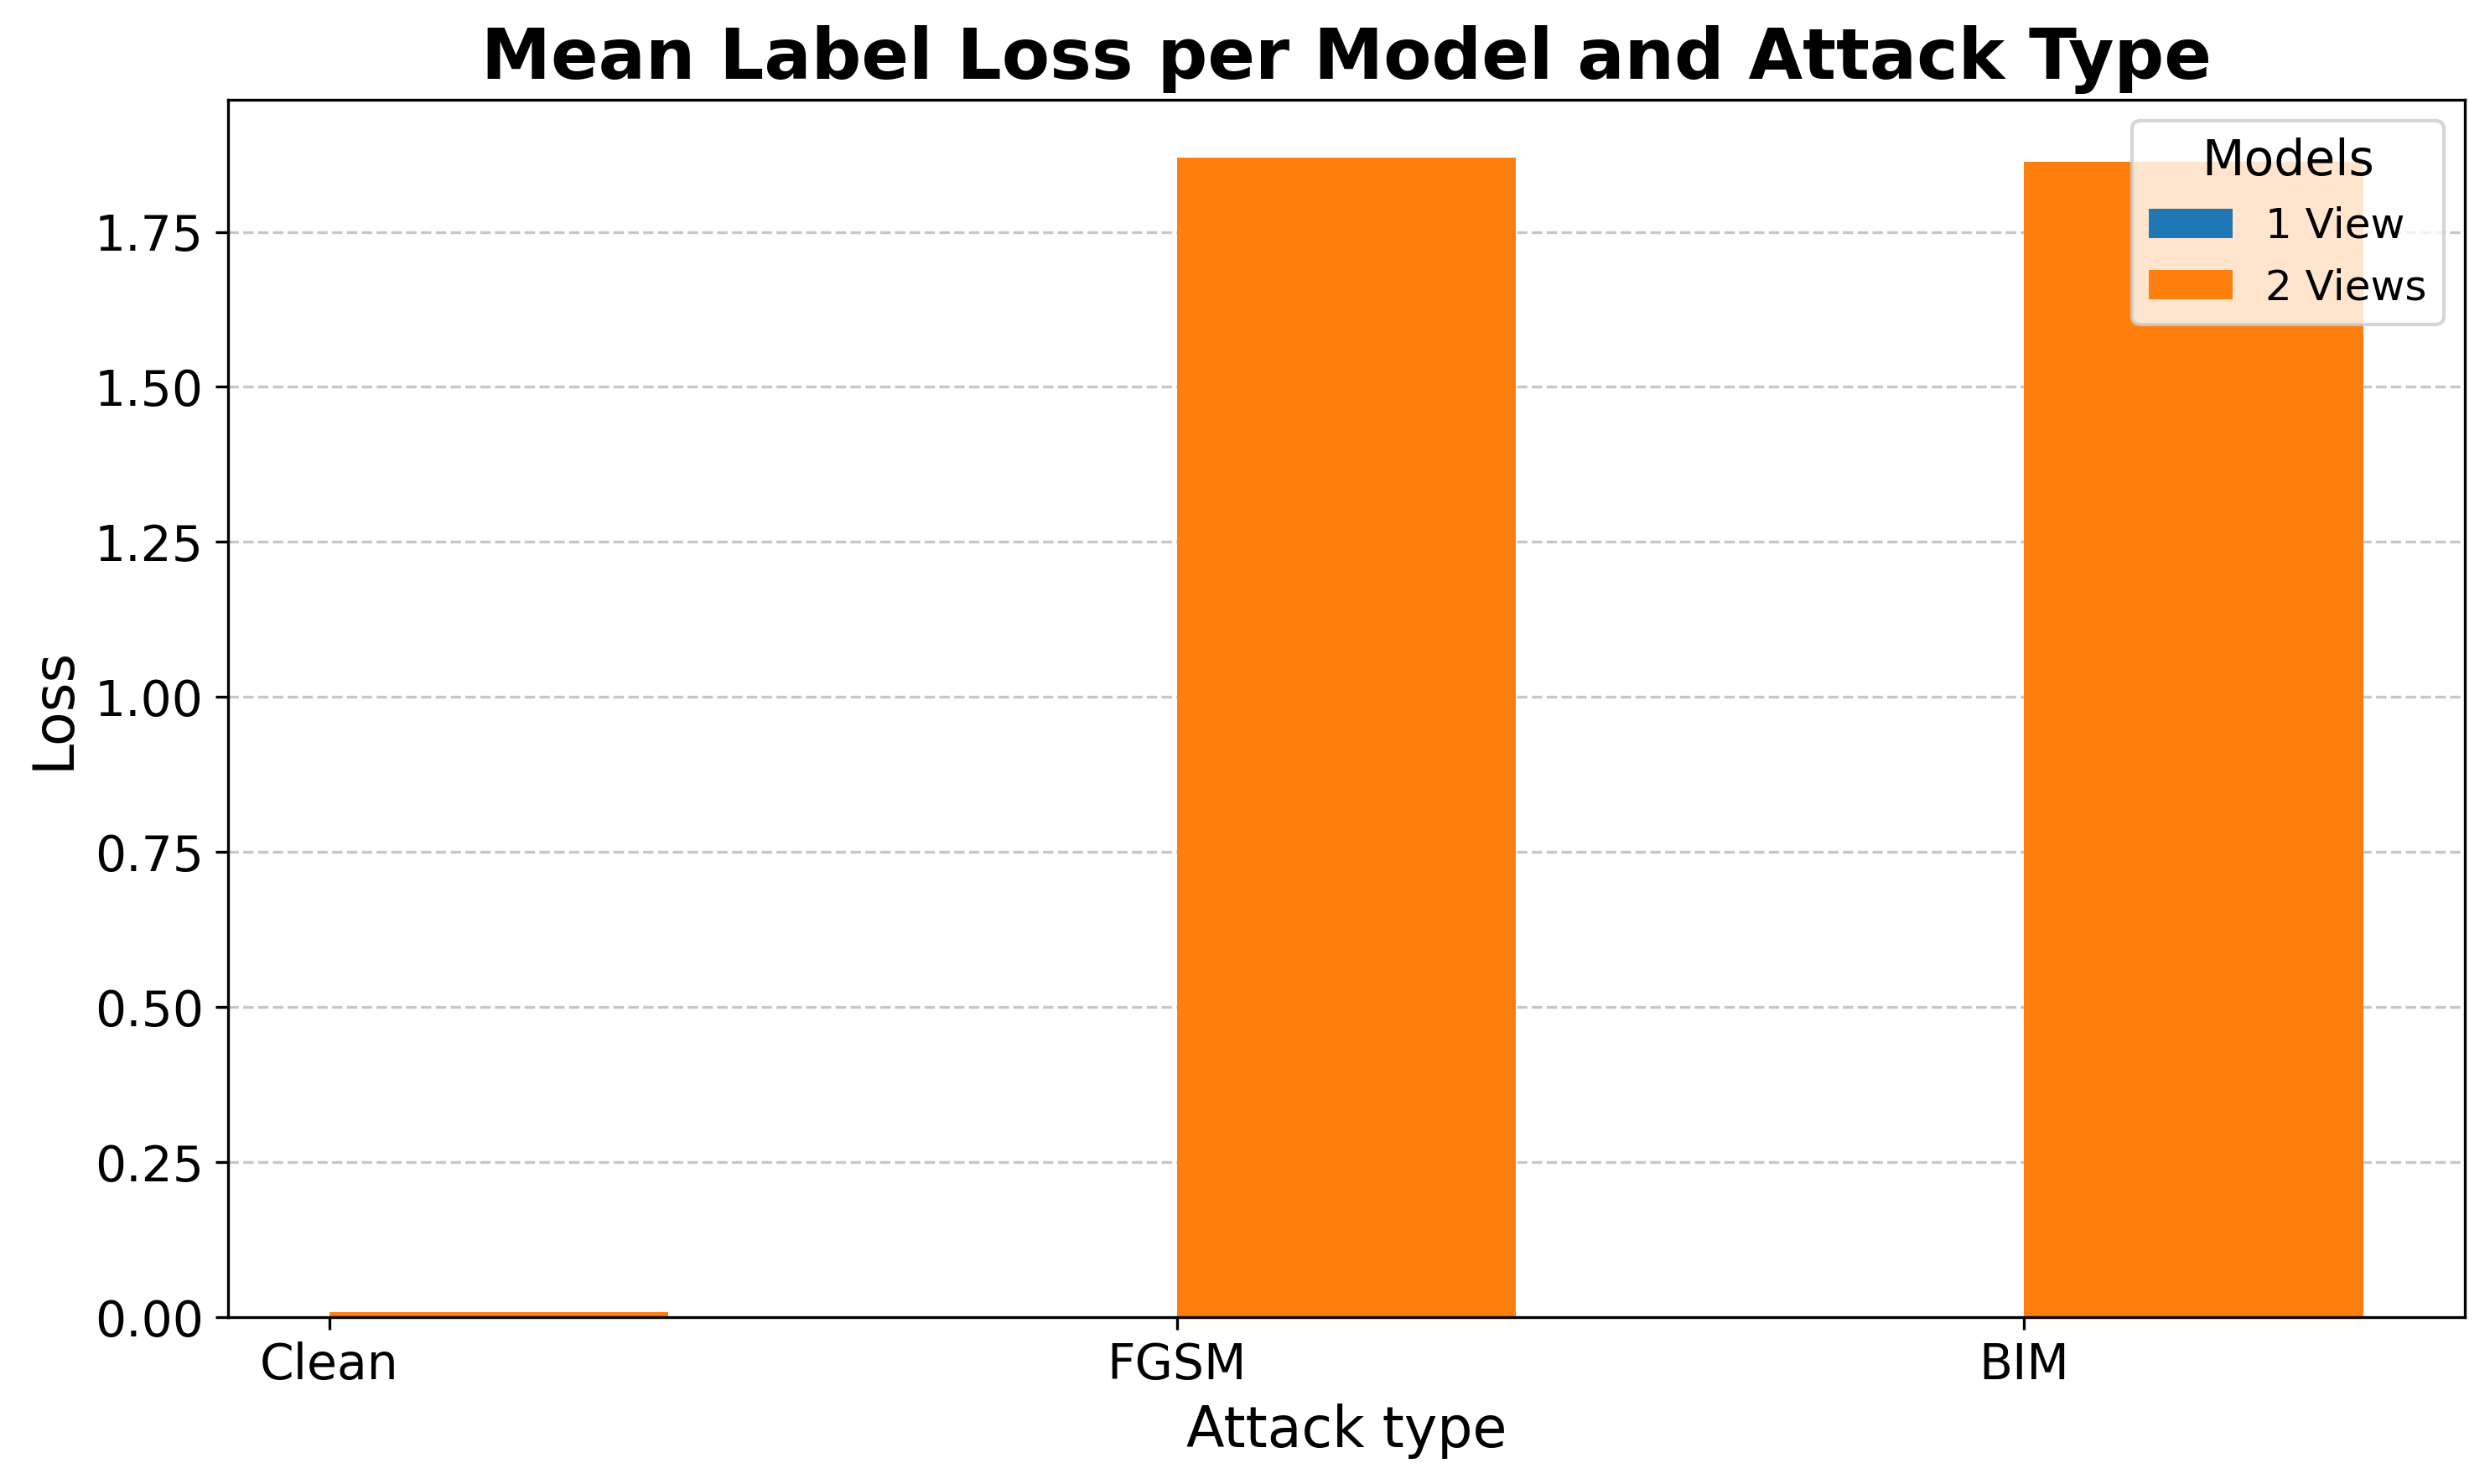

In [10]:
plot_model_attack_losses(mean_label_loss, view='LA')


In [11]:
## Increase plots


In [18]:
df_inc = add_increase_columns(df)
df_inc

,model,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss,FGSM_IM_Abs_Increase,FGSM_IM_Rel_Increase,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase,FGSM_LA_Abs_Increase,FGSM_LA_Rel_Increase,BIM_LA_Abs_Increase,BIM_LA_Rel_Increase
0,1V,0.007930,0.037863,0.009118,NaN,NaN,NaN,0.029933,377.466323,0.001188,14.974876,NaN,NaN,NaN,NaN
1,1V,0.008155,0.039692,0.009431,NaN,NaN,NaN,0.031538,386.745925,0.001276,15.649184,NaN,NaN,NaN,NaN
2,1V,0.007724,0.037606,0.008867,NaN,NaN,NaN,0.029881,386.858940,0.001143,14.799029,NaN,NaN,NaN,NaN
3,1V,0.007812,0.038582,0.008980,NaN,NaN,NaN,0.030769,393.852627,0.001168,14.948240,NaN,NaN,NaN,NaN
4,1V,0.007602,0.007602,0.007602,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
5,1V,0.008287,0.040250,0.009553,NaN,NaN,NaN,0.031963,385.677892,0.001266,15.274931,NaN,NaN,NaN,NaN
6,1V,0.007914,0.038026,0.009110,NaN,NaN,NaN,0.030112,380.487406,0.001196,15.118009,NaN,NaN,NaN,NaN
7,1V,0.007288,0.035751,0.008363,NaN,NaN,NaN,0.028463,390.557093,0.001076,14.757895,NaN,NaN,NaN,NaN
8,1V,0.007276,0.037630,0.008409,NaN,NaN,NaN,0.030355,417.216227,0.001133,15.578175,NaN,NaN,NaN,NaN
9,1V,0.008127,0.039070,0.009390,NaN,NaN,NaN,0.030943,380.727436,0.001263,15.538609,NaN,NaN,NaN,NaN


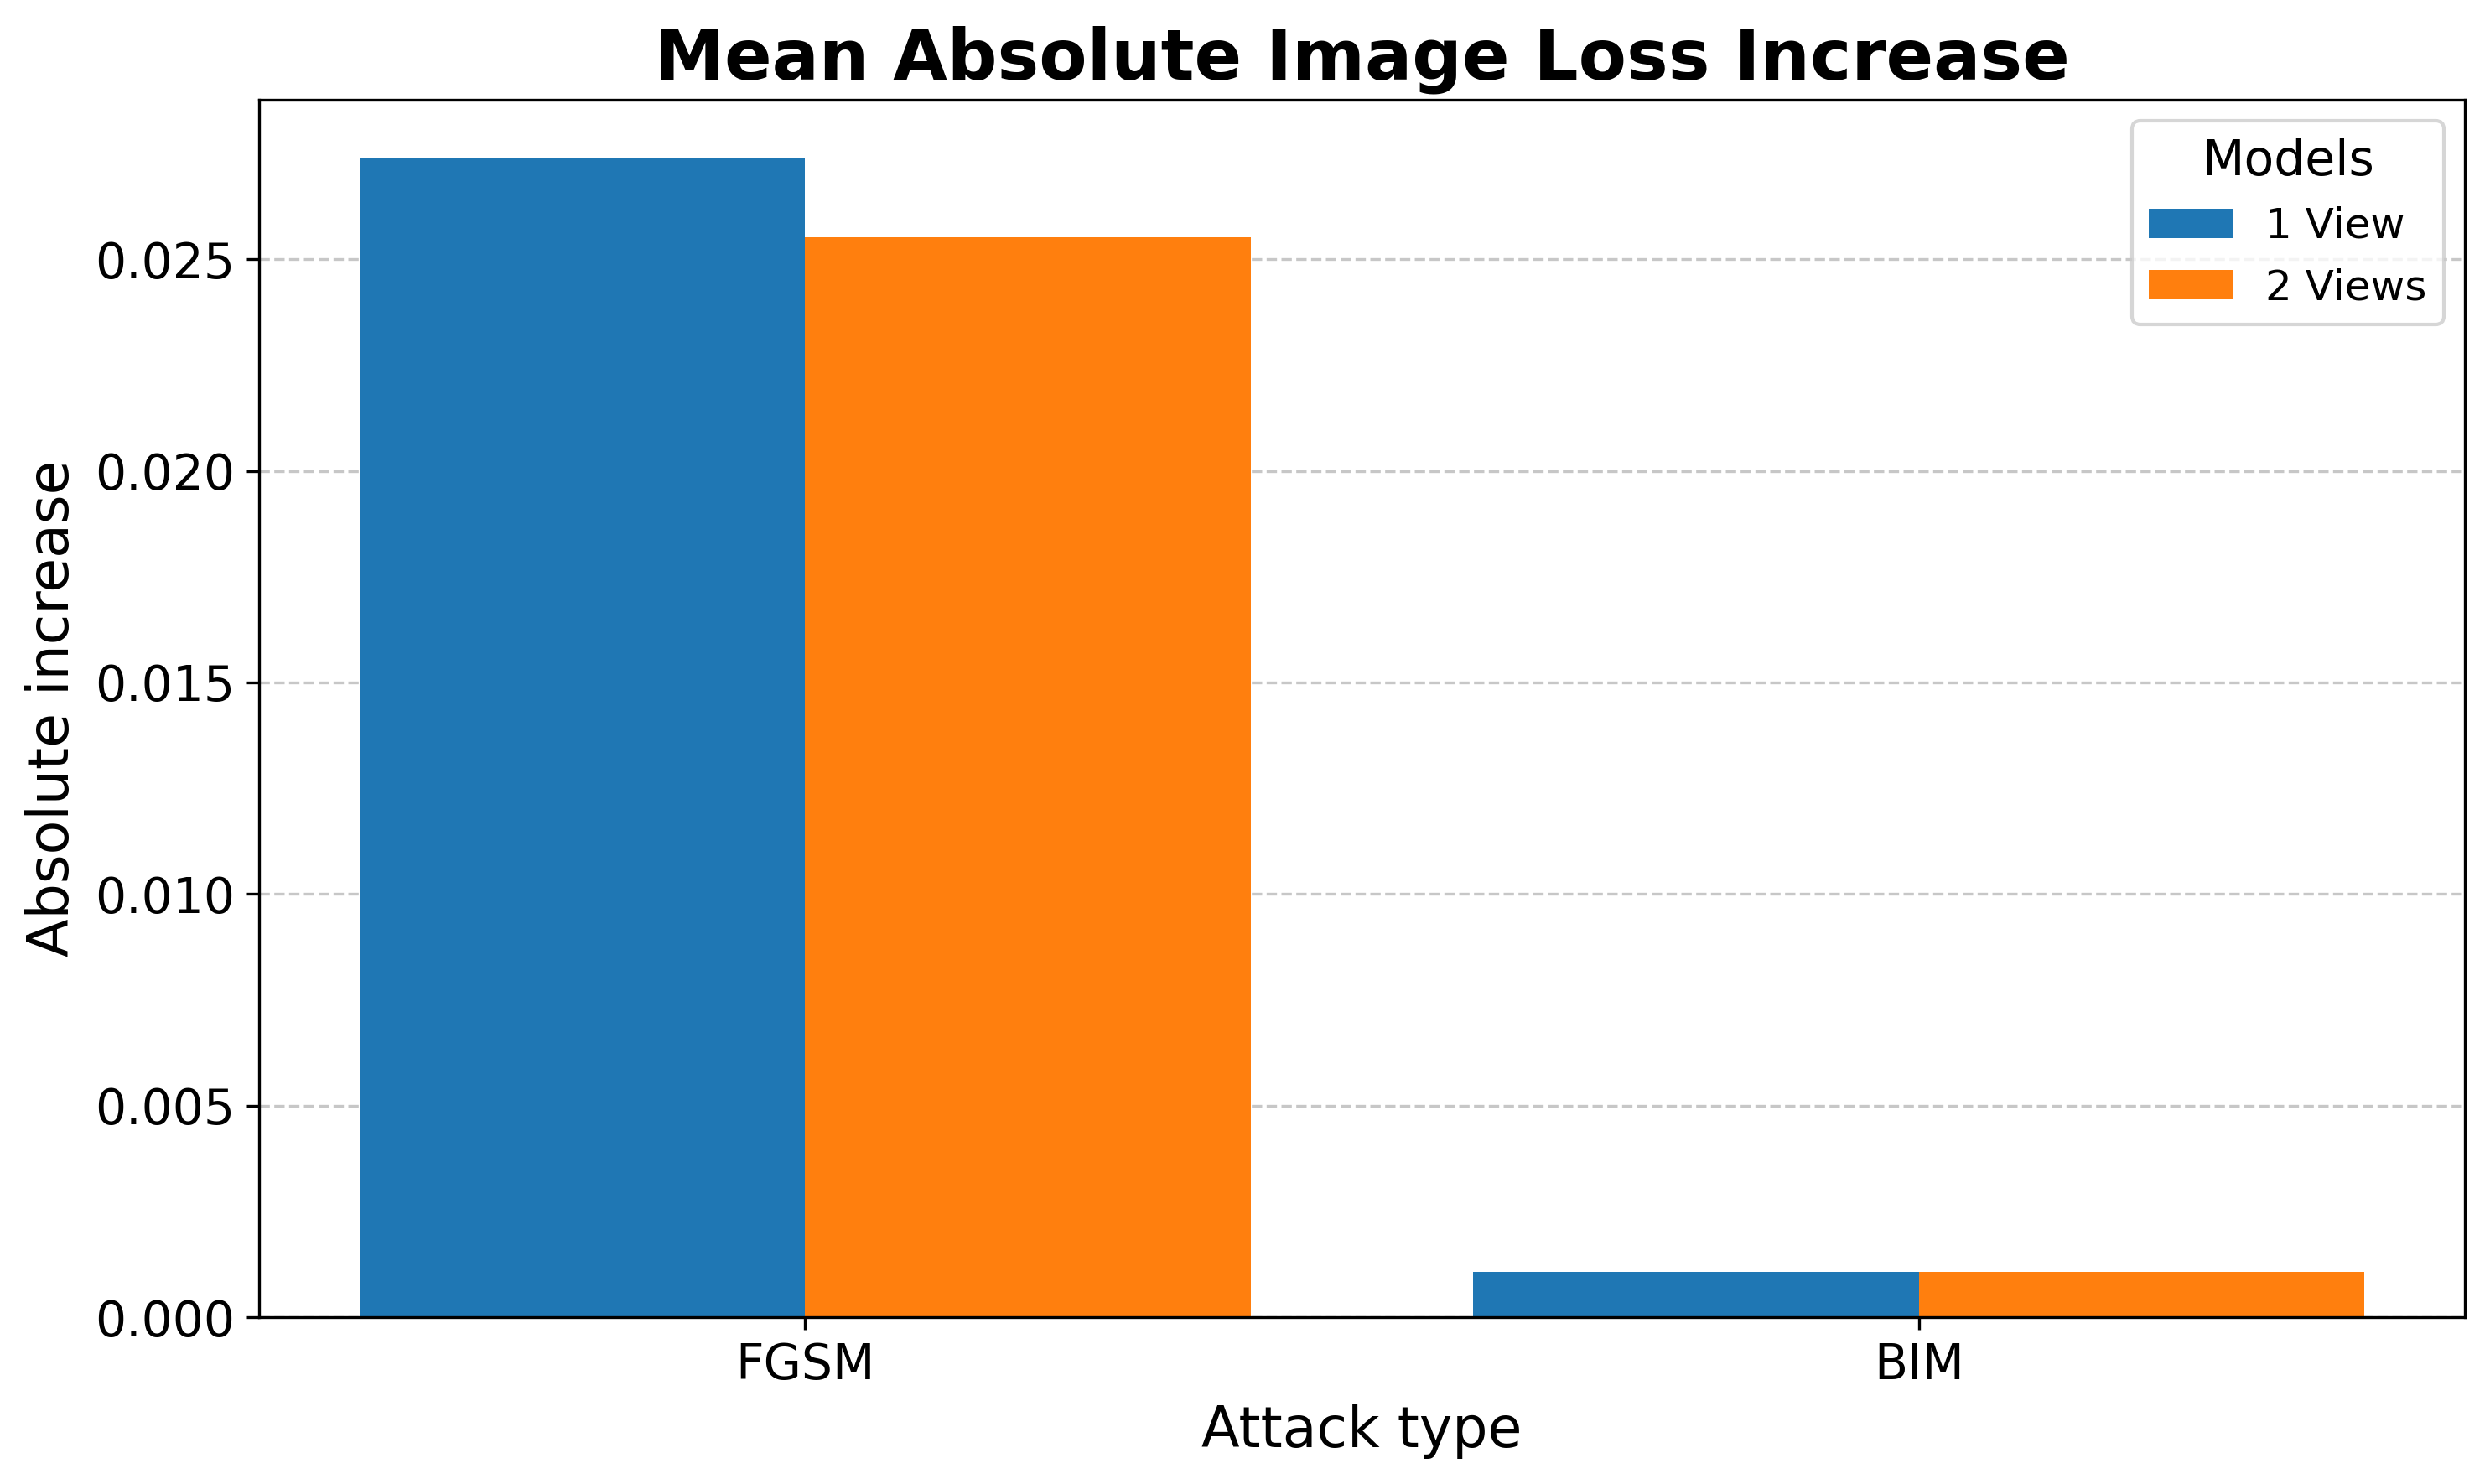

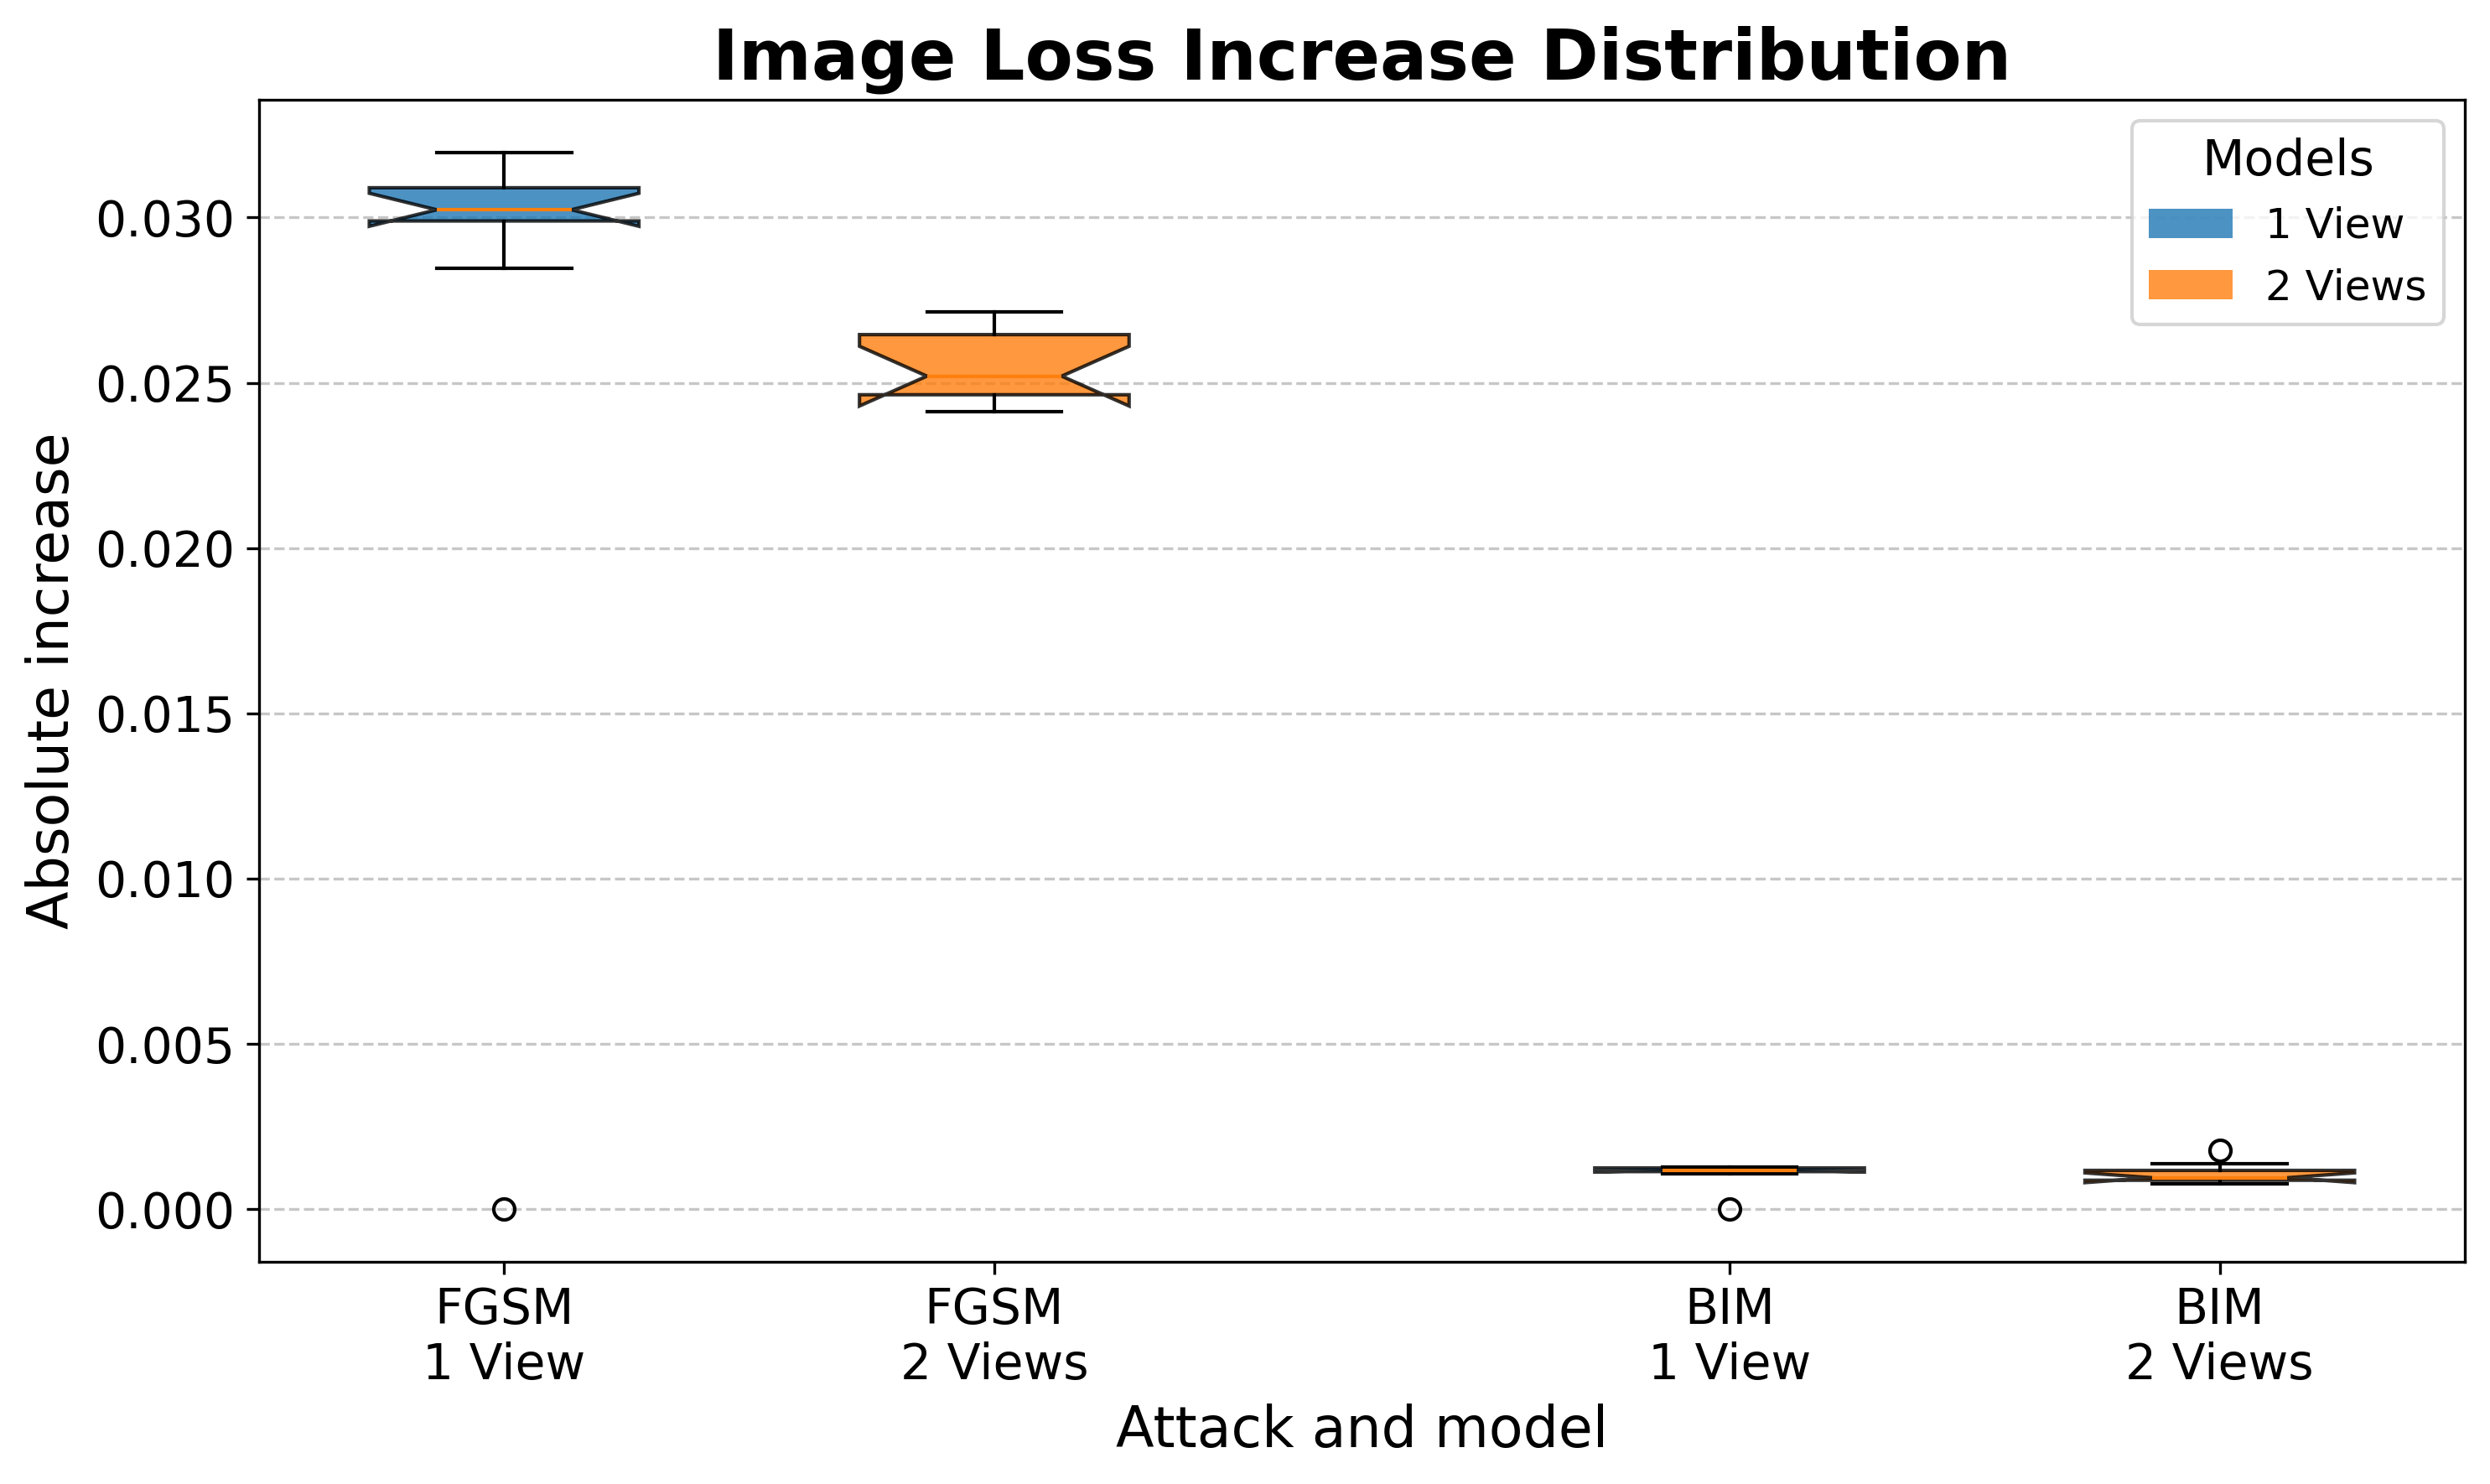

In [13]:
plot_absolute_increases(df_inc, view='IM')
plot_increase_boxplots(df_inc, view='IM', increase_type='Abs')


plot_absolute_increases(df_inc, view='LA')
plot_increase_boxplots(df_inc, view='LA', increase_type='Abs')


## Statistical tests

In [15]:
def normality_by_model(data, value_col, alpha=0.05):
    """Run Shapiro-Wilk normality tests for every model."""
    all_normal = True

    print(f'Normality test for {value_col}:')

    for model in MODEL_ORDER:
        values = data.loc[data['model'].eq(model), value_col].dropna().to_numpy()
        stat, p_value = stats.shapiro(values)

        print(f'{MODEL_LABEL_MAP[model]}: W = {stat:.4f}, p = {p_value:.4f}')

        if p_value < alpha:
            all_normal = False

    return all_normal


def print_pairwise_groups(p_value, alpha=0.05):
    """Compact letter display for two models."""
    if p_value < alpha:
        groups = pd.Series(['a', 'b'], index=[MODEL_LABEL_MAP[m] for m in MODEL_ORDER])
    else:
        groups = pd.Series(['a', 'a'], index=[MODEL_LABEL_MAP[m] for m in MODEL_ORDER])

    print('\nPost-hoc groups:')
    print(groups)

    return groups


def anova_by_model(data, value_col, alpha=0.05):
    """Run one-way ANOVA. With two models, the post-hoc groups follow from the ANOVA p-value."""
    groups = get_groups(data, value_col)
    f_stat, p_value = stats.f_oneway(*groups)

    print(f'ANOVA: F = {f_stat:.4f}, p = {p_value:.6e}')
    cld = print_pairwise_groups(p_value, alpha=alpha)

    return f_stat, p_value, cld


def kruskal_by_model(data, value_col, alpha=0.05):
    """Run Kruskal-Wallis. With two models, the post-hoc groups follow from the Kruskal p-value."""
    groups = get_groups(data, value_col)
    h_stat, p_value = kruskal(*groups)

    print(f'Kruskal-Wallis: H = {h_stat:.4f}, p = {p_value:.6e}')
    cld = print_pairwise_groups(p_value, alpha=alpha)

    return h_stat, p_value, cld


def statistical_test_by_model(data, value_col, alpha=0.05):
    """Use ANOVA when all model groups are normal, otherwise Kruskal-Wallis."""
    print(f'\n===== {value_col} =====')

    all_normal = normality_by_model(data, value_col, alpha=alpha)
    print()

    if all_normal:
        return anova_by_model(data, value_col, alpha=alpha)

    return kruskal_by_model(data, value_col, alpha=alpha)


In [16]:
# Statistical tests on the raw reconstruction losses.
for view in VIEWS:
    for loss_col in LOSS_COL_MAP[view].values():
        statistical_test_by_model(df, loss_col)
        print('\n' + '-' * 60)



===== Clean_IM_Loss =====
Normality test for Clean_IM_Loss:
1 View: W = 0.9388, p = 0.5395
2 Views: W = 0.9388, p = 0.5395

ANOVA: F = 0.0000, p = 1.000000e+00

Post-hoc groups:
1 View     a
2 Views    a
dtype: object

------------------------------------------------------------

===== FGSM_IM_Loss =====
Normality test for FGSM_IM_Loss:
1 View: W = 0.4865, p = 0.0000
2 Views: W = 0.9312, p = 0.4599

Kruskal-Wallis: H = 9.1429, p = 2.496909e-03

Post-hoc groups:
1 View     a
2 Views    b
dtype: object

------------------------------------------------------------

===== BIM_IM_Loss =====
Normality test for BIM_IM_Loss:
1 View: W = 0.9046, p = 0.2459
2 Views: W = 0.9777, p = 0.9517

ANOVA: F = 0.0000, p = 9.957854e-01

Post-hoc groups:
1 View     a
2 Views    a
dtype: object

------------------------------------------------------------

===== Clean_LA_Loss =====
Normality test for Clean_LA_Loss:
1 View: W = nan, p = nan
2 Views: W = 0.9683, p = 0.8743

ANOVA: F = nan, p = nan

Post-hoc g

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_43480/857800420.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = stats.shapiro(values)
/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_43480/857800420.py:35: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*groups)


## Statistical tests on attack increases


In [17]:
# Statistical tests on the absolute attack-induced increases.
for view in VIEWS:
    for attack in ATTACKS:
        increase_col = f'{attack}_{view}_Abs_Increase'
        statistical_test_by_model(df_inc, increase_col)
        print('\n' + '-' * 60)



===== FGSM_IM_Abs_Increase =====
Normality test for FGSM_IM_Abs_Increase:
1 View: W = 0.4602, p = 0.0000
2 Views: W = 0.9208, p = 0.3635

Kruskal-Wallis: H = 9.1429, p = 2.496909e-03

Post-hoc groups:
1 View     a
2 Views    b
dtype: object

------------------------------------------------------------

===== BIM_IM_Abs_Increase =====
Normality test for BIM_IM_Abs_Increase:
1 View: W = 0.5250, p = 0.0000
2 Views: W = 0.8450, p = 0.0507

Kruskal-Wallis: H = 1.4629, p = 2.264761e-01

Post-hoc groups:
1 View     a
2 Views    a
dtype: object

------------------------------------------------------------

===== FGSM_LA_Abs_Increase =====
Normality test for FGSM_LA_Abs_Increase:
1 View: W = nan, p = nan
2 Views: W = 0.9672, p = 0.8642

ANOVA: F = nan, p = nan

Post-hoc groups:
1 View     a
2 Views    a
dtype: object

------------------------------------------------------------

===== BIM_LA_Abs_Increase =====
Normality test for BIM_LA_Abs_Increase:
1 View: W = nan, p = nan
2 Views: W = 0.9345

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_43480/857800420.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = stats.shapiro(values)
/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_43480/857800420.py:35: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*groups)
